In [1]:
from ema_workbench import (
    Model, Policy, ema_logging,
    MultiprocessingEvaluator, save_results, load_results, Scenario
)
from ema_workbench.analysis import prim, cart, parcoords
from sklearn.preprocessing import minmax_scale
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from problem_formulation import get_model_for_problem_formulation
from dike_model_function import DikeNetwork
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from concurrent.futures import ProcessPoolExecutor
import os
import itertools
import functools
import random
from assignment_10_scenario_selection import find_maxdiverse_scenarios
from ema_workbench.analysis import dimensional_stacking

In [2]:
dike_model, planning_steps = get_model_for_problem_formulation(3)

In [109]:
for i in dike_model.outcomes:
    print(i)


ScalarOutcome('A.1 Total Costs', variable_name=('A.1_Expected Annual Damage', 'A.1_Dike Investment Costs'), function=<function sum_over at 0x11eafef20>)
ScalarOutcome('A.1_Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths',), function=<function sum_over at 0x11eafef20>)
ScalarOutcome('A.2 Total Costs', variable_name=('A.2_Expected Annual Damage', 'A.2_Dike Investment Costs'), function=<function sum_over at 0x11eafef20>)
ScalarOutcome('A.2_Expected Number of Deaths', variable_name=('A.2_Expected Number of Deaths',), function=<function sum_over at 0x11eafef20>)
ScalarOutcome('A.3 Total Costs', variable_name=('A.3_Expected Annual Damage', 'A.3_Dike Investment Costs'), function=<function sum_over at 0x11eafef20>)
ScalarOutcome('A.3_Expected Number of Deaths', variable_name=('A.3_Expected Number of Deaths',), function=<function sum_over at 0x11eafef20>)
ScalarOutcome('A.4 Total Costs', variable_name=('A.4_Expected Annual Damage', 'A.4_Dike Investment Costs'), functio

In [3]:
# Enable logging
ema_logging.log_to_stderr(ema_logging.INFO)

# Load model formulation
dike_model, planning_steps = get_model_for_problem_formulation(3)

# Create a "do nothing" policy (no investment in any lever)
do_nothing = Policy("do nothing", **{lev.name: 0 for lev in dike_model.levers})

# Choose number of scenarios
n_scenarios = 10000  # Literature suggests 1000–10,000, this is a balanced choice

# Run model for scenarios with 1 policy
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=n_scenarios, policies=[do_nothing])
    save_results(results, "scenario_selection.tar.gz")

[MainProcess/INFO] pool started with 12 workers
[MainProcess/INFO] performing 10000 scenarios * 1 policies * 1 model(s) = 10000 experiments
100%|████████████████████████████████████| 10000/10000 [12:56<00:00, 12.87it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] results saved successfully to C:\Users\milan\PycharmProjects\EMAworkbench\final assignment\scenario_selection.tar.gz
[MainProcess/INFO] terminating pool


In [3]:
# Load experiments and outcomes from saved file
experiments, outcomes = load_results('scenario_selection.tar.gz')

In [4]:
# 1 = median filter, 2 = percentile filter, 3 = diversity-based selection
SELECTION_METHOD = 3  # Change this to 1, 2, or 3

# Define outcomes and preferences
outcome_names = [
    'RfR Total Costs',
    'Expected Evacuation Costs',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths'
]
preferences = {name: +1 for name in outcome_names}  # All to be minimized

# --- SCENARIO FILTERING ---
if SELECTION_METHOD == 1:
    # Median-based filtering
    thresholds = {o: np.median(outcomes[o]) for o in outcome_names}
    y = np.ones(len(experiments), dtype=bool)
    for o in outcome_names:
        if preferences[o] == +1:
            y &= outcomes[o] >= thresholds[o]
        else:
            y &= outcomes[o] <= thresholds[o]

elif SELECTION_METHOD == 2:
    # Percentile-based filtering
    percentile_threshold = 90  # Choose percentile for "worse" scenarios
    thresholds = {
        o: np.percentile(outcomes[o], percentile_threshold if preferences[o] == +1 else (100 - percentile_threshold))
        for o in outcome_names
    }
    y = np.ones(len(experiments), dtype=bool)
    for o in outcome_names:
        if preferences[o] == +1:
            y &= outcomes[o] >= thresholds[o]
        else:
            y &= outcomes[o] <= thresholds[o]

elif SELECTION_METHOD == 3:
    # No initial filtering for diversity; use all experiments
    y = np.ones(len(experiments), dtype=bool)

else:
    raise ValueError("Invalid SELECTION_METHOD. Choose 1 (median), 2 (percentile), or 3 (diversity)")

# Subset experiments and outcomes
experiments_of_interest = experiments.loc[y]
outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items() if k in outcome_names})

# --- SCENARIO SELECTION ---
if SELECTION_METHOD == 3:
    # --- DIVERSITY-BASED SELECTION ---
    scaler = MinMaxScaler()
    normalized_outcomes = pd.DataFrame(
        scaler.fit_transform(outcomes_df),
        columns=outcomes_df.columns,
        index=outcomes_df.index
    )

    distances = squareform(pdist(normalized_outcomes.values))
    sampled_combinations = [random.sample(range(len(normalized_outcomes)), 5) for _ in range(10000000)]

    partial_function = functools.partial(find_maxdiverse_scenarios, distances)
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        worker_data = np.array_split(sampled_combinations, os.cpu_count())
        results = list(itertools.chain.from_iterable(executor.map(partial_function, worker_data)))

    results.sort(key=lambda entry: entry[0], reverse=True)
    diversity_score, best_indices = results[0]

    print(f"\nMost diverse scenario indices: {best_indices}")

else:
    # --- BEST/WORST-CASE AGGREGATED SELECTION ---
    scaler = MinMaxScaler()
    normalized_outcomes = pd.DataFrame(
        scaler.fit_transform(outcomes_df),
        columns=outcomes_df.columns,
        index=outcomes_df.index
    )

    best_index = normalized_outcomes.sum(axis=1).idxmin()
    worst_index = normalized_outcomes.sum(axis=1).idxmax()
    best_indices = [
        normalized_outcomes.index.get_loc(best_index),
        normalized_outcomes.index.get_loc(worst_index)
    ]

    print(f"\nBest/Worst scenario indices: {[best_index, worst_index]}")

# --- Common output ---
true_indices = outcomes_df.iloc[list(best_indices)].index
selected_experiments = experiments.loc[true_indices]
selected_outcomes = pd.DataFrame({k: outcomes[k][true_indices] for k in outcome_names})


Most diverse scenario indices: [7284 6572 7638 8006 2927]


In [5]:
selected_outcomes

,RfR Total Costs,Expected Evacuation Costs,A.5 Total Costs,A.5_Expected Number of Deaths
0,0.0,0.0,1.036482e+09,0.989237
1,0.0,0.0,0.000000e+00,0.000000
2,0.0,0.0,6.117546e+08,0.671569
3,0.0,0.0,4.766608e+08,0.334794
4,0.0,0.0,1.564111e+09,1.197884


In [7]:
type(selected_experiments)

pandas.core.frame.DataFrame

In [9]:
selected_experiments

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
7284,58,180.947664,10.0,0.833816,333.489628,1.0,0.509235,30.526142,1.5,0.700647,...,0,0,0,0,0,0,0,7284,do nothing,dikesnet
6572,89,182.082884,10.0,0.003718,251.367552,1.0,0.486604,49.841388,1.0,0.633640,...,0,0,0,0,0,0,0,6572,do nothing,dikesnet
7638,36,167.798248,10.0,0.656545,275.795062,10.0,0.541815,243.445608,10.0,0.822534,...,0,0,0,0,0,0,0,7638,do nothing,dikesnet
8006,77,72.908195,1.0,0.294116,168.050401,1.5,0.451919,265.622466,1.0,0.668413,...,0,0,0,0,0,0,0,8006,do nothing,dikesnet
2927,70,271.452405,1.5,0.661892,116.974563,10.0,0.640391,286.008882,1.5,0.898327,...,0,0,0,0,0,0,0,2927,do nothing,dikesnet


In [10]:
selected_experiments.to_csv("selected_experiments.csv", index=True)

In [11]:
selected_experiments = pd.read_csv("selected_experiments.csv", index_col=0)

In [12]:
selected_experiments

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
7284,58,180.947664,10.0,0.833816,333.489628,1.0,0.509235,30.526142,1.5,0.700647,...,0,0,0,0,0,0,0,7284,do nothing,dikesnet
6572,89,182.082884,10.0,0.003718,251.367552,1.0,0.486604,49.841388,1.0,0.633640,...,0,0,0,0,0,0,0,6572,do nothing,dikesnet
7638,36,167.798248,10.0,0.656545,275.795062,10.0,0.541815,243.445608,10.0,0.822534,...,0,0,0,0,0,0,0,7638,do nothing,dikesnet
8006,77,72.908195,1.0,0.294116,168.050401,1.5,0.451919,265.622466,1.0,0.668413,...,0,0,0,0,0,0,0,8006,do nothing,dikesnet
2927,70,271.452405,1.5,0.661892,116.974563,10.0,0.640391,286.008882,1.5,0.898327,...,0,0,0,0,0,0,0,2927,do nothing,dikesnet


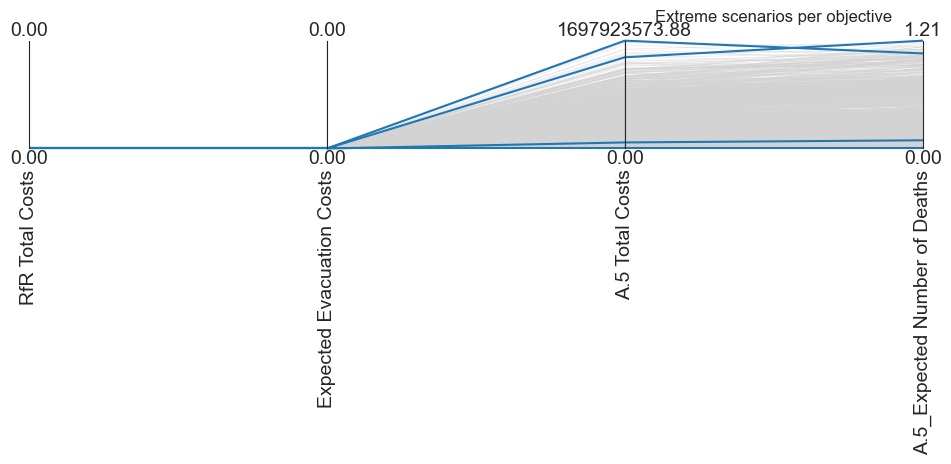

In [13]:
# STEP 4: Parallel coordinates plot with extremes
all_data = pd.DataFrame({k: outcomes[k] for k in outcome_names})
extreme_indices = pd.concat([all_data.idxmin(), all_data.idxmax()]).unique()
limits = parcoords.get_limits(all_data)
axes = parcoords.ParallelAxes(limits)
axes.plot(all_data, color='lightgrey', lw=0.5, alpha=0.5)
axes.plot(all_data.loc[extreme_indices], color=sns.color_palette()[0], lw=1.5)
fig = plt.gcf()
fig.set_size_inches((10, 4))
plt.title("Extreme scenarios per objective")
plt.show()


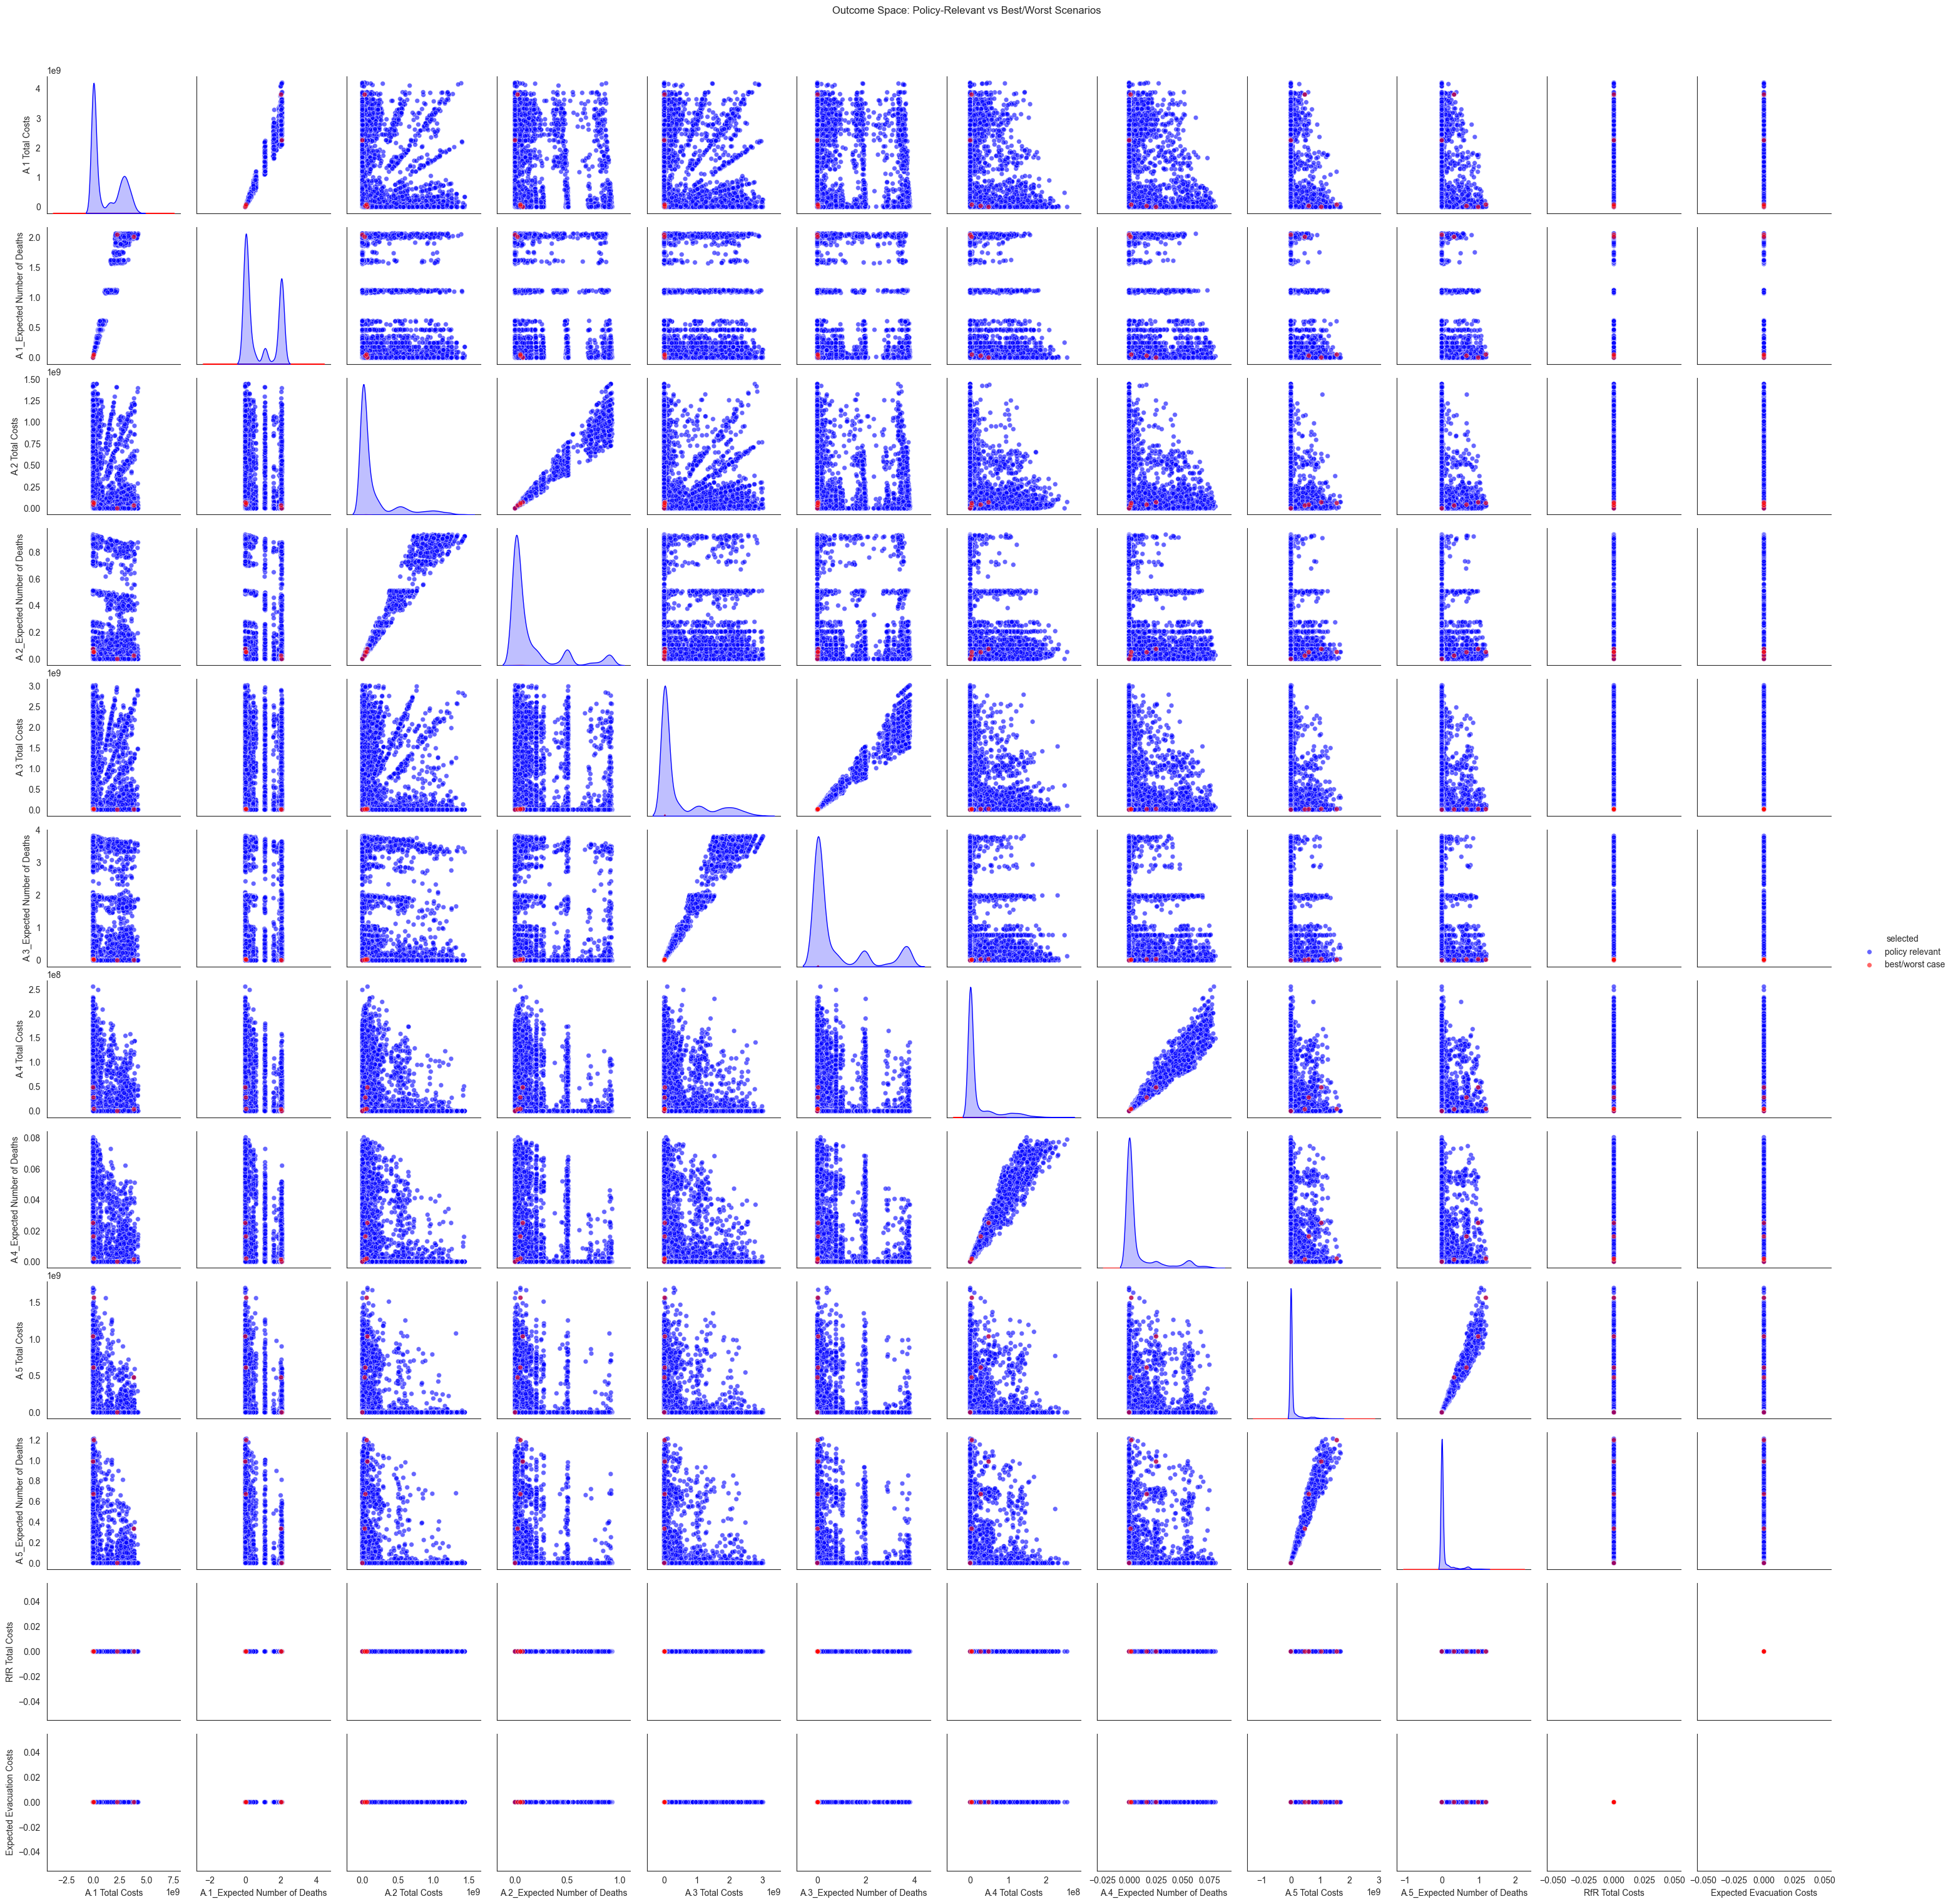

In [14]:
# STEP 5: Full outcome space pairplot (all outcomes)
full_outcomes_df = pd.DataFrame({k: v[y] for k, v in outcomes.items()})
full_outcomes_df = full_outcomes_df.copy()
full_outcomes_df['selected'] = 'policy relevant'
selected_labeled = full_outcomes_df.loc[true_indices].copy()
selected_labeled['selected'] = 'best/worst case'
combined_outcomes = pd.concat([full_outcomes_df, selected_labeled])

sns.pairplot(
    combined_outcomes,
    vars=full_outcomes_df.columns.drop('selected'),
    hue='selected',
    palette={'policy relevant': 'blue', 'best/worst case': 'red'},
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle('Outcome Space: Policy-Relevant vs Best/Worst Scenarios', y=1.02)
plt.show()


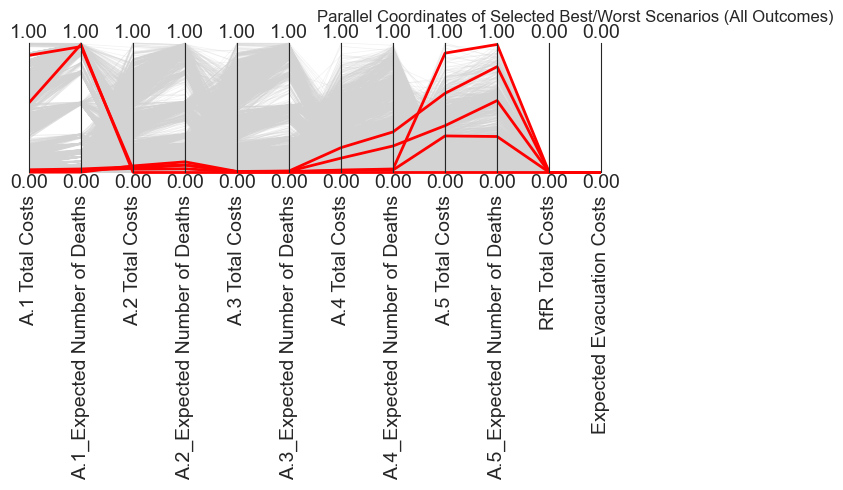

In [15]:
from sklearn.preprocessing import minmax_scale
from ema_workbench.analysis import parcoords

# Use all outcomes (not just selected ones)
full_combined_data = pd.DataFrame({k: v[y] for k, v in outcomes.items()})  # only policy-relevant
normalized_all = full_combined_data.copy()
normalized_all[full_combined_data.columns] = minmax_scale(full_combined_data)

# Selected 2 (best and worst case) from earlier
selected_out = normalized_all.loc[true_indices]

# Plot full space and highlight best/worst
limits = parcoords.get_limits(normalized_all)
ax = parcoords.ParallelAxes(limits)
ax.plot(normalized_all, color='lightgrey', lw=0.5, alpha=0.3)
ax.plot(selected_out, color='red', lw=2)
plt.title('Parallel Coordinates of Selected Best/Worst Scenarios (All Outcomes)')
plt.show()

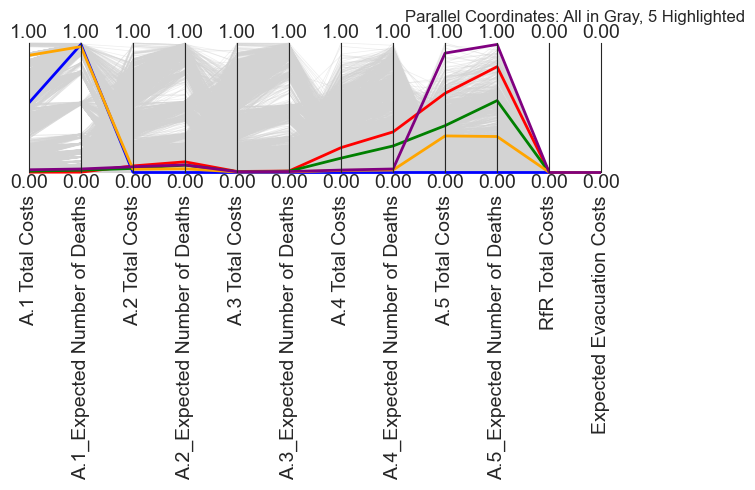

In [16]:
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.preprocessing import minmax_scale
from ema_workbench.analysis import parcoords

# Normalize the full set of outcomes (filtered for policy relevance)
full_combined_data = pd.DataFrame({k: v[y] for k, v in outcomes.items()})
normalized_all = full_combined_data.copy()
normalized_all[full_combined_data.columns] = minmax_scale(full_combined_data)

# Get normalized rows for selected scenarios (5 of them)
selected_out = normalized_all.loc[true_indices]

# Set limits
limits = parcoords.get_limits(normalized_all)
ax = parcoords.ParallelAxes(limits)

# Plot all scenarios in gray
ax.plot(normalized_all, color='lightgray', lw=0.5, alpha=0.4)

# Plot selected scenarios in unique colors
highlight_colors = ['red', 'blue', 'green', 'orange', 'purple']  # or use colormap
for i, (idx, row) in enumerate(selected_out.iterrows()):
    color = highlight_colors[i % len(highlight_colors)]
    ax.plot(row.to_frame().T, color=color, lw=2)

plt.title('Parallel Coordinates: All in Gray, 5 Highlighted')
plt.show()

In [17]:
outcomes_df['A.5_Expected Number of Deaths'].describe()

count    10000.000000
mean         0.063010
std          0.181006
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000439
max          1.212415
Name: A.5_Expected Number of Deaths, dtype: float64

In [18]:
outcomes_df

,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,9.538282e+07,0.092241,0.0,0.0
1,0.000000e+00,0.000000,0.0,0.0
2,0.000000e+00,0.000000,0.0,0.0
3,0.000000e+00,0.000000,0.0,0.0
4,0.000000e+00,0.000000,0.0,0.0
...,...,...,...,...
9995,0.000000e+00,0.000000,0.0,0.0
9996,4.047126e+06,0.004261,0.0,0.0
9997,0.000000e+00,0.000000,0.0,0.0
9998,0.000000e+00,0.000000,0.0,0.0


[MainProcess/INFO] column policy dropped from analysis because it has only one category
[MainProcess/INFO] column model dropped from analysis because it has only one category
[MainProcess/INFO] 10000 points remaining, containing 2208 cases of interest
[MainProcess/INFO] mean: 0.9984848484848485, mass: 0.066, coverage: 0.29846014492753625, density: 0.9984848484848485 restricted_dimensions: 5


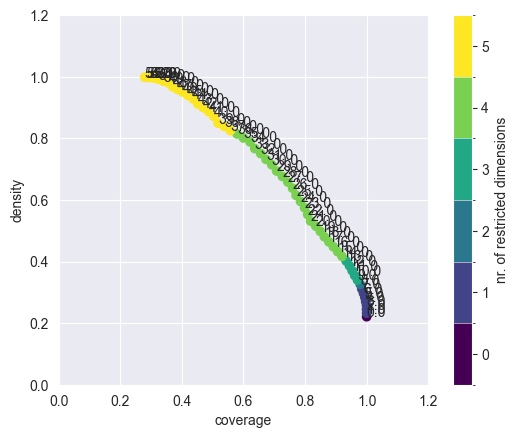

In [11]:
from ema_workbench.analysis import prim

# Binary classification mask for PRIM
# Top 25% van scenario's met hoogste sterfte
threshold = 0.01
y_prim = outcomes_df['A.5_Expected Number of Deaths'] > threshold

# Use experiments_of_interest (same length as y_prim)

prim_alg = prim.Prim(experiments_of_interest, y_prim, threshold=0.8)
box = prim_alg.find_box()
box.show_tradeoff(annotated=True)
plt.show()

In [29]:
experiments_of_interest

,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.3_DikeIncrease 2,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,scenario,policy,model
0,24,32.292112,1.5,0.176063,310.257746,1.5,0.420761,159.622109,10.0,0.002416,...,0,0,0,0,0,0,0,0,do nothing,dikesnet
1,30,194.871632,1.0,0.270516,86.467084,1.5,0.029978,39.549552,1.0,0.323596,...,0,0,0,0,0,0,0,1,do nothing,dikesnet
2,77,281.979045,10.0,0.097353,178.819301,10.0,0.920528,138.672963,1.5,0.734291,...,0,0,0,0,0,0,0,2,do nothing,dikesnet
3,76,311.260935,1.0,0.926289,57.475277,10.0,0.843096,342.017174,1.5,0.435626,...,0,0,0,0,0,0,0,3,do nothing,dikesnet
4,56,212.773024,1.0,0.243288,139.068511,1.5,0.721194,209.996761,1.5,0.659489,...,0,0,0,0,0,0,0,4,do nothing,dikesnet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,27,172.285677,1.5,0.313729,87.569960,1.5,0.528111,182.597233,1.5,0.111986,...,0,0,0,0,0,0,0,9995,do nothing,dikesnet
9996,81,218.519422,1.5,0.521833,305.372507,10.0,0.291990,149.541350,10.0,0.736208,...,0,0,0,0,0,0,0,9996,do nothing,dikesnet
9997,48,151.222492,10.0,0.098592,310.583676,10.0,0.112668,115.991036,1.0,0.257541,...,0,0,0,0,0,0,0,9997,do nothing,dikesnet
9998,74,31.598103,10.0,0.325665,256.993354,10.0,0.512050,178.513675,1.5,0.281868,...,0,0,0,0,0,0,0,9998,do nothing,dikesnet


In [30]:
outcomes_df

,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,0.000000e+00,0.000000,0.0,0.0
1,0.000000e+00,0.000000,0.0,0.0
2,0.000000e+00,0.000000,0.0,0.0
3,4.657194e+08,0.458392,0.0,0.0
4,0.000000e+00,0.000000,0.0,0.0
...,...,...,...,...
9995,0.000000e+00,0.000000,0.0,0.0
9996,0.000000e+00,0.000000,0.0,0.0
9997,0.000000e+00,0.000000,0.0,0.0
9998,0.000000e+00,0.000000,0.0,0.0


In [31]:
y_prim

0       False
1       False
2       False
3        True
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: A.5_Expected Number of Deaths, Length: 10000, dtype: bool

In [ ]:
#Hier evt nog wat toevoegen om een aparte box te inspecteren

In [32]:
point = 27
box.inspect(point)

coverage       0.730665
density        0.650781
id            27.000000
k           1625.000000
mass           0.249700
mean           0.650781
n           2497.000000
res_dim        4.000000
Name: 27, dtype: float64

             box 27                                       
                min       max      qp value       qp value
A.5_pfail  0.000021  0.357396           NaN  1.751184e-302
A.3_pfail  0.182679  0.999963  2.337153e-18            NaN
A.2_pfail  0.095945  0.999943  1.085947e-06            NaN
A.4_pfail  0.048780  0.999907  5.874487e-03            NaN



[None]

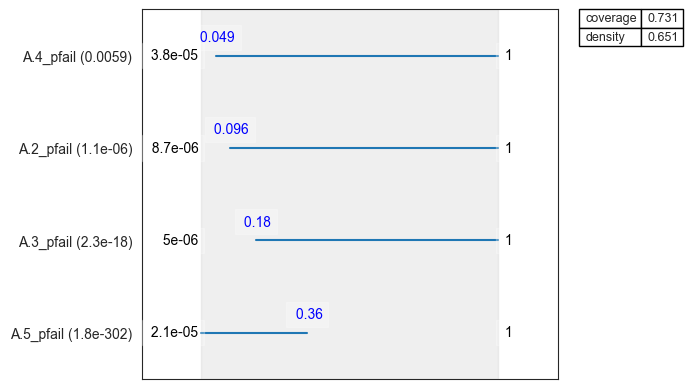

In [33]:
box.inspect(point, style='graph')
plt.show()

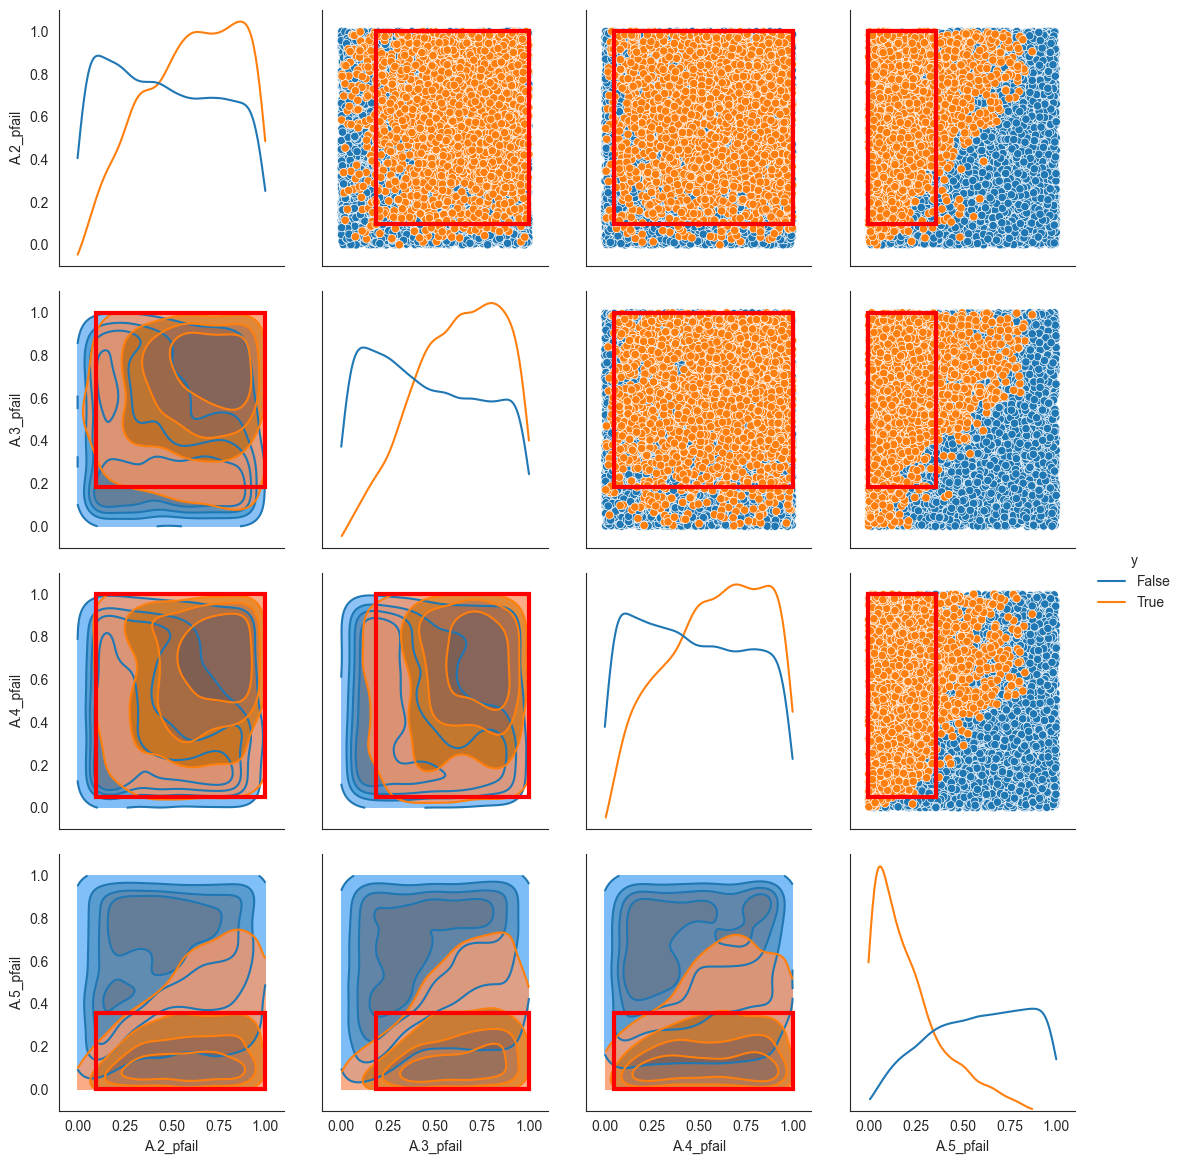

In [34]:
box.select(point)
box.show_pairs_scatter()
fig = plt.gcf()
fig.set_size_inches(12,12)
plt.show()

In [35]:
y_array = y_prim.values

/var/folders/64/05z9tvhd1mn8h92shl8zdmwr0000gn/T/ipykernel_12097/1255276283.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 800x600 with 0 Axes>

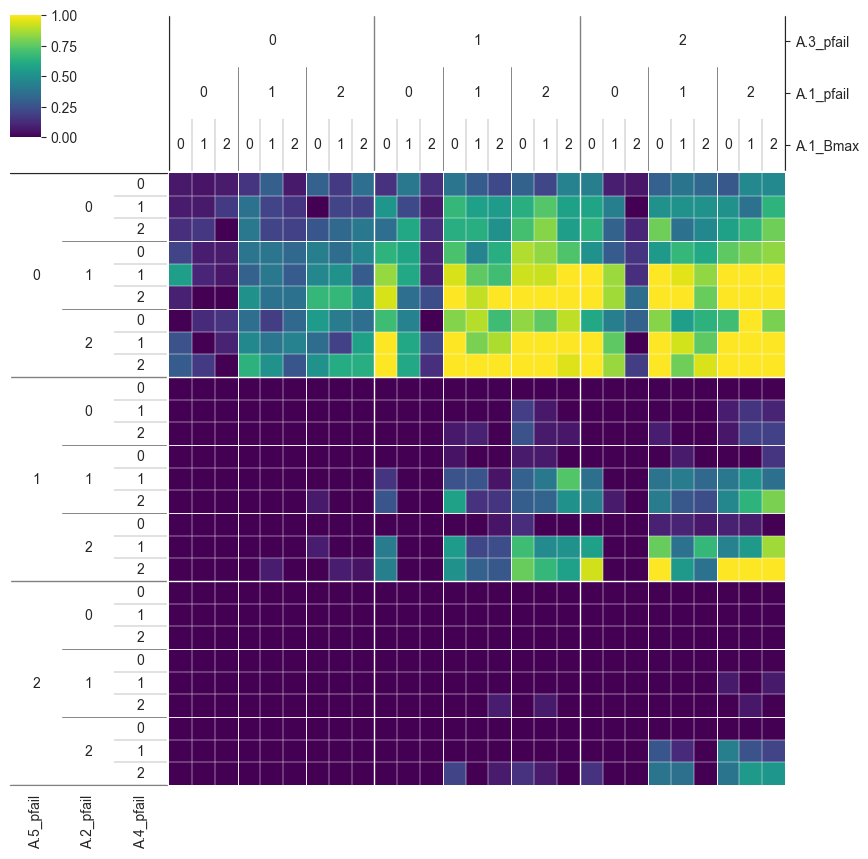

In [36]:
#Hier kan Dimensional Stacking
plt.figure(figsize=(8, 6))
dimensional_stacking.create_pivot_plot(experiments_of_interest, y_array)
plt.tight_layout()
plt.show()

In [19]:
import multiprocessing
print("Number of CPU cores:", multiprocessing.cpu_count())

Number of CPU cores: 8


In [20]:
from ema_workbench import ema_logging, Scenario
from ema_workbench.em_framework.optimization import (
    ArchiveLogger, EpsilonProgress, to_problem, epsilon_nondominated
)
from ema_workbench import MultiprocessingEvaluator
from problem_formulation import get_model_for_problem_formulation

import pandas as pd
import os

# === Cleaning utilities ===
def clean_name(name, prefix="L_"):
    clean = name.replace(" ", "_").replace(".", "_").replace("-", "_")
    if clean[0].isdigit():
        clean = prefix + clean
    return clean

def clean_column_names(df, prefix="L_"):
    df = df.copy()
    df.columns = [clean_name(col, prefix=prefix) for col in df.columns]
    return df

# === Configuration ===
objectives_of_interest = [
    "RfR Total Costs",
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]

cleaned_objectives_of_interest = [clean_name(o, "O_") for o in objectives_of_interest]

In [21]:
# === Optimization function Kwakkel-style ===
import copy
def optimize_scenario(scenario, nfe, model, epsilons):
    # Create a deep copy of the model for problem definition
    import copy
    model_for_problem = copy.deepcopy(model)
    names_to_keep = []
    for o in model_for_problem.outcomes:
        if o.name in objectives_of_interest:
            names_to_keep.append(o.name)

    for name in list(model_for_problem.outcomes.keys()):
        if name not in names_to_keep:
            del model_for_problem.outcomes[name]

    # Clean names for problem definition
    for lever in model_for_problem.levers:
        lever.name = clean_name(lever.name, "L_")
    for outcome in model_for_problem.outcomes:
        outcome.name = clean_name(outcome.name, "O_")

    problem = to_problem(model_for_problem, searchover="levers")
    problem._outcome_names = cleaned_objectives_of_interest

    names_to_keep = []
    for o in model.outcomes:
       if o.name in objectives_of_interest:
           names_to_keep.append(o.name)

    for name in list(model.outcomes.keys()):
       if name not in names_to_keep:
           del model.outcomes[name]

    reference_scenario = scenario

    results = []
    convergences = []
    # problem is now created above from cleaned model

    lever_names = [clean_name(l.name, "L_") for l in model.levers]
    outcome_names = [clean_name(o.name, "O_") for o in model.outcomes]

    os.makedirs("./archives", exist_ok=True)

    with MultiprocessingEvaluator(model) as evaluator:
        for run_id in range(5):
            archive_filename = f"optimization2_{scenario.name}_run{run_id}.tar.gz"
            archive_path = f"./archives/{archive_filename}"
            if os.path.exists(archive_path):
                os.remove(archive_path)

            convergence_metrics = [
                ArchiveLogger("./archives", lever_names, outcome_names, base_filename=archive_filename),
                EpsilonProgress()
            ]

            print(f"🔁 Running optimization for scenario {scenario.name}, run {run_id}")
            result, convergence = evaluator.optimize(
                nfe=nfe,
                searchover='levers',
                convergence=convergence_metrics,
                epsilons=epsilons,
                reference=reference_scenario
            )

            result = clean_column_names(result)
            results.append(result)
            convergences.append(convergence)

            #archive_loaded = ArchiveLogger.load_archives(archive_path)
            #archive_cleaned = {k: clean_column_names(v) for k, v in archive_loaded.items()}
            #archive_path_clean = f"./archives/cleaned_{scenario.name}_run{run_id}.csv"
            #archive_cleaned[max(archive_cleaned.keys())].to_csv(archive_path_clean, index=False)
            #print(f"💾 Cleaned archive saved to {archive_path_clean}")

    # Optional: merge all results across 5 runs for the scenario
    reference_set = epsilon_nondominated(results, epsilons, problem)
    return reference_set, convergences

In [22]:
from ema_workbench import Scenario

# Maak een lijst met Scenario-objecten
scenarios = [
    Scenario(f"Scenario_{i}", **row.to_dict())
    for i, row in selected_experiments.iterrows()
]

In [23]:
experiments_range, outcomes_range = load_results("ema_resultsprobstate3.tar.gz")

In [24]:
import numpy as np

# Convert outcomes to a DataFrame
outcomes_df_test = pd.DataFrame({k: v.flatten() for k, v in outcomes_range.items()})

# Your original list of outcomes of interest
objectives_of_interest = [
    "RfR Total Costs",
    "A.5 Total Costs",
    "A.5_Expected Number of Deaths"
]


# Calculate range per objective and derive epsilons
epsilons = []
for obj in objectives_of_interest:
    min_val = outcomes_df_test[obj].min()
    max_val = outcomes_df_test[obj].max()
    range_val = max_val - min_val
    epsilon = 0.1 * range_val  # or try 0.02 if you want to be more relaxed
    epsilons.append(epsilon)
    print(f"{obj}: min={min_val:.2f}, max={max_val:.2f}, range={range_val:.2f}, epsilon={epsilon:.2f}")

RfR Total Costs: min=84600000.00, max=2046600000.00, range=1962000000.00, epsilon=196200000.00
A.5 Total Costs: min=25037214.09, max=1414669089.82, range=1389631875.73, epsilon=138963187.57
A.5_Expected Number of Deaths: min=0.00, max=1.06, range=1.06, epsilon=0.11


In [25]:
outcomes_df_test["A.5_Expected Number of Deaths"].describe()

count    300000.000000
mean          0.003567
std           0.020352
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000058
max           1.056032
Name: A.5_Expected Number of Deaths, dtype: float64

In [26]:
epsilons = [
    50_000_000,         # RfR Total Costs
    200_000_000,        # A.5 Total Costs
    0.001                 # A.5 Deaths
]

In [27]:
epsilons

[50000000, 200000000, 0.001]

In [28]:
model, _ = get_model_for_problem_formulation(3)

results = []
for scenario in scenarios:
    # note that 100000 nfe is again rather low to ensure proper convergence
    results.append(optimize_scenario(scenario, 10000, model, epsilons))

🔁 Running optimization for scenario Scenario_7284, run 0


100%|████████████████████████████████████| 10000/10000 [08:43<00:00, 19.09it/s]


🔁 Running optimization for scenario Scenario_7284, run 1


100%|████████████████████████████████████| 10000/10000 [09:01<00:00, 18.46it/s]


🔁 Running optimization for scenario Scenario_7284, run 2


...

100%|████████████████████████████████████| 10000/10000 [08:17<00:00, 20.08it/s]


🔁 Running optimization for scenario Scenario_2927, run 3


100%|████████████████████████████████████| 10000/10000 [08:19<00:00, 20.02it/s]


🔁 Running optimization for scenario Scenario_2927, run 4


100%|████████████████████████████████████| 10000/10000 [08:17<00:00, 20.11it/s]


In [29]:
# Unpack tuples with only (ref_set, convergence_data)
all_results_df = pd.concat([df for df, _ in results])
max_vals = all_results_df[cleaned_objectives_of_interest].max().tolist()
print("Auto-detected HV max values:", max_vals)

Auto-detected HV max values: [242400000.0, 58176627.77592012, 0.0]


In [30]:
for i, (df, _) in enumerate(results):
    print(f"Scenario {i}: {len(df)} non-dominated solutions")
print(f"Total across all scenarios: {len(all_results_df)}")

Scenario 0: 1 non-dominated solutions
Scenario 1: 1 non-dominated solutions
Scenario 2: 1 non-dominated solutions
Scenario 3: 1 non-dominated solutions
Scenario 4: 2 non-dominated solutions
Total across all scenarios: 6


In [31]:
for obj in cleaned_objectives_of_interest:
    print(obj, all_results_df[obj].min(), all_results_df[obj].max())

RfR_Total_Costs 0.0 242400000.0
A_5_Total_Costs 0.0 58176627.77592012
A_5_Expected_Number_of_Deaths 0.0 0.0


In [21]:
from platypus import Hypervolume
from ema_workbench.em_framework.optimization import rebuild_platypus_population

def calculate_convergence_metrics(problem, archive_path, max_vals):
    hv = Hypervolume(minimum=[0] * len(cleaned_objectives_of_interest), maximum=max_vals)
    archives = ArchiveLogger.load_archives(archive_path)
    metrics = []
    for nfe, archive in archives.items():
        population = rebuild_platypus_population(archive, problem)
        metrics.append(dict(hypervolume=hv.calculate(population), nfe=nfe))
    df = pd.DataFrame(metrics)
    df.sort_values(by="nfe", inplace=True, ignore_index=True)
    return df

model_for_problem = copy.deepcopy(model)
names_to_keep = []
for o in model_for_problem.outcomes:
    if o.name in objectives_of_interest:
        names_to_keep.append(o.name)

for name in list(model_for_problem.outcomes.keys()):
    if name not in names_to_keep:
        del model_for_problem.outcomes[name]

# Clean names for problem definition
for lever in model_for_problem.levers:
    lever.name = clean_name(lever.name, "L_")
for outcome in model_for_problem.outcomes:
    outcome.name = clean_name(outcome.name, "O_")

problem = to_problem(model_for_problem, searchover="levers")
problem._outcome_names = cleaned_objectives_of_interest
convergence_calculations = []
for (refset, eps_progress), scenario in zip(results, scenarios):
    for seed, seed_eps in zip(range(5), eps_progress):
        archive_file = f"./archives/optimization_{scenario.name}_run{seed}.tar.gz"
        metrics = calculate_convergence_metrics(problem, archive_file, max_vals)
        metrics["seed"] = seed
        metrics["scenario"] = scenario.name
        metrics["epsilon_progress"] = seed_eps.epsilon_progress

        convergence_calculations.append(metrics)
convergence = pd.concat(convergence_calculations, ignore_index=True)

PlatypusError: objective with empty range

<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
C:\Users\milan\AppData\Local\Temp\ipykernel_22132\2858807176.py:20: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('$\epsilon$ progress')


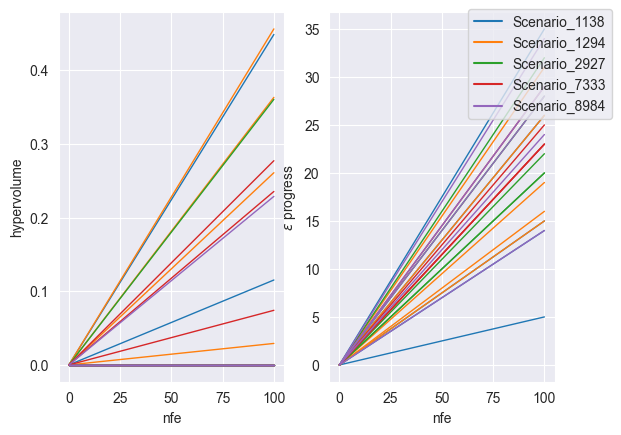

In [26]:
import matplotlib as mpl
import seaborn as sns


fig, (ax1, ax2) = plt.subplots(ncols=2)

colors = sns.color_palette()

legend_items = []
for (scenario_name, scores), color in zip(convergence.groupby("scenario"), colors):
    # we use this for a custom legend
    legend_items.append((mpl.lines.Line2D([0, 0], [1, 1], c=color), scenario_name))
    for seed, score in scores.groupby("seed"):
        ax1.plot(score.nfe, score.hypervolume, c=color, lw=1)
        ax2.plot(score.nfe, score.epsilon_progress, c=color, lw=1)


ax1.set_ylabel('hypervolume')
ax1.set_xlabel('nfe')
ax2.set_ylabel('$\epsilon$ progress')
ax2.set_xlabel('nfe')

# create our custom legend
artists, labels = zip(*legend_items)
fig.legend(artists, labels, bbox_to_anchor=(1,0.9))

plt.show()

In [32]:
from ema_workbench import Policy

policies = []
for i, (result, _) in enumerate(results):
    result = result.iloc[:, 0:31]
    for j, row in result.iterrows():
        policy = Policy(f'scenario {i} option {j}', **row.to_dict())
        policies.append(policy)

In [41]:
policies

[Policy({'L_0_RfR_0': 0, 'L_0_RfR_1': 0, 'L_0_RfR_2': 0, 'L_1_RfR_0': 0, 'L_1_RfR_1': 0, 'L_1_RfR_2': 0, 'L_2_RfR_0': 0, 'L_2_RfR_1': 0, 'L_2_RfR_2': 0, 'L_3_RfR_0': 0, 'L_3_RfR_1': 0, 'L_3_RfR_2': 0, 'L_4_RfR_0': 0, 'L_4_RfR_1': 0, 'L_4_RfR_2': 0, 'EWS_DaysToThreat': 0, 'A_1_DikeIncrease_0': 5, 'A_1_DikeIncrease_1': 4, 'A_1_DikeIncrease_2': 3, 'A_2_DikeIncrease_0': 4, 'A_2_DikeIncrease_1': 2, 'A_2_DikeIncrease_2': 4, 'A_3_DikeIncrease_0': 0, 'A_3_DikeIncrease_1': 0, 'A_3_DikeIncrease_2': 0, 'A_4_DikeIncrease_0': 6, 'A_4_DikeIncrease_1': 0, 'A_4_DikeIncrease_2': 6, 'A_5_DikeIncrease_0': 4, 'A_5_DikeIncrease_1': 0, 'A_5_DikeIncrease_2': 0}),
 Policy({'L_0_RfR_0': 0, 'L_0_RfR_1': 0, 'L_0_RfR_2': 0, 'L_1_RfR_0': 0, 'L_1_RfR_1': 0, 'L_1_RfR_2': 0, 'L_2_RfR_0': 0, 'L_2_RfR_1': 0, 'L_2_RfR_2': 0, 'L_3_RfR_0': 0, 'L_3_RfR_1': 0, 'L_3_RfR_2': 0, 'L_4_RfR_0': 0, 'L_4_RfR_1': 0, 'L_4_RfR_2': 0, 'EWS_DaysToThreat': 0, 'A_1_DikeIncrease_0': 10, 'A_1_DikeIncrease_1': 3, 'A_1_DikeIncrease_2': 5, 'A_

In [33]:
from ema_workbench import Policy

# Define the name mapping
rename_map = {
    'L_0_RfR_0': '0_RfR 0',
    'L_0_RfR_1': '0_RfR 1',
    'L_0_RfR_2': '0_RfR 2',
    'L_1_RfR_0': '1_RfR 0',
    'L_1_RfR_1': '1_RfR 1',
    'L_1_RfR_2': '1_RfR 2',
    'L_2_RfR_0': '2_RfR 0',
    'L_2_RfR_1': '2_RfR 1',
    'L_2_RfR_2': '2_RfR 2',
    'L_3_RfR_0': '3_RfR 0',
    'L_3_RfR_1': '3_RfR 1',
    'L_3_RfR_2': '3_RfR 2',
    'L_4_RfR_0': '4_RfR 0',
    'L_4_RfR_1': '4_RfR 1',
    'L_4_RfR_2': '4_RfR 2',
    'EWS_DaysToThreat': 'EWS_DaysToThreat',
    'A_1_DikeIncrease_0': 'A.1_DikeIncrease 0',
    'A_1_DikeIncrease_1': 'A.1_DikeIncrease 1',
    'A_1_DikeIncrease_2': 'A.1_DikeIncrease 2',
    'A_2_DikeIncrease_0': 'A.2_DikeIncrease 0',
    'A_2_DikeIncrease_1': 'A.2_DikeIncrease 1',
    'A_2_DikeIncrease_2': 'A.2_DikeIncrease 2',
    'A_3_DikeIncrease_0': 'A.3_DikeIncrease 0',
    'A_3_DikeIncrease_1': 'A.3_DikeIncrease 1',
    'A_3_DikeIncrease_2': 'A.3_DikeIncrease 2',
    'A_4_DikeIncrease_0': 'A.4_DikeIncrease 0',
    'A_4_DikeIncrease_1': 'A.4_DikeIncrease 1',
    'A_4_DikeIncrease_2': 'A.4_DikeIncrease 2',
    'A_5_DikeIncrease_0': 'A.5_DikeIncrease 0',
    'A_5_DikeIncrease_1': 'A.5_DikeIncrease 1',
    'A_5_DikeIncrease_2': 'A.5_DikeIncrease 2',
}

def rename_policy_levers(policies):
    renamed_policies = []
    for i, policy in enumerate(policies):
        new_values = {rename_map.get(k, k): v for k, v in policy.items()}
        renamed_policies.append(Policy(str(i), **new_values))
    return renamed_policies
# original_policies is your list of Policy objects
renamed_policies = rename_policy_levers(policies)


In [44]:
for i in dike_model.levers:
    print(i)

0_RfR 0
0_RfR 1
0_RfR 2
1_RfR 0
1_RfR 1
1_RfR 2
2_RfR 0
2_RfR 1
2_RfR 2
3_RfR 0
3_RfR 1
3_RfR 2
4_RfR 0
4_RfR 1
4_RfR 2
EWS_DaysToThreat
A.1_DikeIncrease 0
A.1_DikeIncrease 1
A.1_DikeIncrease 2
A.2_DikeIncrease 0
A.2_DikeIncrease 1
A.2_DikeIncrease 2
A.3_DikeIncrease 0
A.3_DikeIncrease 1
A.3_DikeIncrease 2
A.4_DikeIncrease 0
A.4_DikeIncrease 1
A.4_DikeIncrease 2
A.5_DikeIncrease 0
A.5_DikeIncrease 1
A.5_DikeIncrease 2


In [72]:
with MultiprocessingEvaluator(dike_model) as evaluator:
    reeevaluation_results = evaluator.perform_experiments(scenarios=1000, policies=renamed_policies)





  0%|                                                 | 0/7000 [00:00<?, ?it/s]



  0%|                                         | 1/7000 [00:00<50:06,  2.33it/s]



  0%|                                         | 9/7000 [00:00<08:34, 13.58it/s]



  0%|                                        | 12/7000 [00:01<08:45, 13.30it/s]



  0%|                                        | 17/7000 [00:01<07:29, 15.52it/s]



  0%|▏                                       | 22/7000 [00:01<05:46, 20.16it/s]



  0%|▏                                       | 25/7000 [00:01<07:52, 14.78it/s]



  0%|▏                                       | 30/7000 [00:01<05:56, 19.55it/s]



  0%|▏                                       | 33/7000 [00:02<08:00, 14.50it/s]



  1%|▏                                       | 36/7000 [00:02<07:04, 16.40it/s]



  1%|▏                                       | 41/7000 [00:02<07:28, 15.52it/s]



  1%|▏                                       | 43/7000 [00:02<08:33, 13.56it/s]





In [74]:
experiments, outcomes = reeevaluation_results

In [78]:
# Create a summary DataFrame
summary_stats = {}

for name, values in outcomes.items():
    summary_stats[name] = {
        'min': np.min(values),
        'max': np.max(values),
        'mean': np.mean(values)
    }

# Convert to DataFrame for easy viewing
summary_df = pd.DataFrame(summary_stats).T  # transpose to get outcomes as rows

In [79]:
summary_df

,min,max,mean
A.1 Total Costs,7.122315e+07,2.503001e+09,2.372313e+08
A.1_Expected Number of Deaths,0.000000e+00,1.238173e+00,5.529999e-02
A.2 Total Costs,0.000000e+00,8.454275e+08,1.648873e+08
A.2_Expected Number of Deaths,0.000000e+00,5.605931e-01,8.903179e-02
A.3 Total Costs,0.000000e+00,1.731548e+09,1.651668e+08
A.3_Expected Number of Deaths,0.000000e+00,2.236710e+00,1.606151e-01
A.4 Total Costs,0.000000e+00,1.690874e+08,3.682336e+07
A.4_Expected Number of Deaths,0.000000e+00,6.304280e-02,3.006623e-03
A.5 Total Costs,0.000000e+00,1.087354e+09,9.145101e+07
A.5_Expected Number of Deaths,0.000000e+00,8.406616e-01,6.521934e-02


In [80]:
experiments, outcomes = reeevaluation_results  # Your reevaluated experiment data

# Define absolute (non-normalized) thresholds for acceptability
thresholds = {
    'A.5_Expected Number of Deaths': 1e-32,
    'A.5 Total Costs': 60_000_000,
    'Expected Evacuation Costs': 1,
    'RfR Total Costs': 100_000_000
}


overall_scores = {}

for policy in experiments.policy.unique():
    logical = experiments.policy == policy
    scores = {}

    for outcome_name, outcome_values in outcomes.items():
        if outcome_name not in thresholds:
            continue  # Only apply thresholds to relevant outcomes

        threshold = thresholds[outcome_name]

        # Check: since these are "less than" thresholds
        n = np.sum(outcome_values[logical] < threshold)
        scores[outcome_name] = n / logical.sum()  # percentage of runs that pass

    overall_scores[policy] = scores

# Convert to DataFrame: rows = policies, columns = outcome pass rates
overall_scores = pd.DataFrame(overall_scores).T

print(overall_scores)


   A.5 Total Costs  A.5_Expected Number of Deaths  RfR Total Costs  \
0            0.902                          0.865              1.0   
1            0.998                          0.998              1.0   
2            0.429                          0.124              1.0   
3            0.609                          0.530              1.0   
4            0.674                          0.534              0.0   
5            0.827                          0.649              0.0   
6            0.700                          0.573              1.0   

   Expected Evacuation Costs  
0                        1.0  
1                        1.0  
2                        1.0  
3                        1.0  
4                        1.0  
5                        1.0  
6                        1.0  


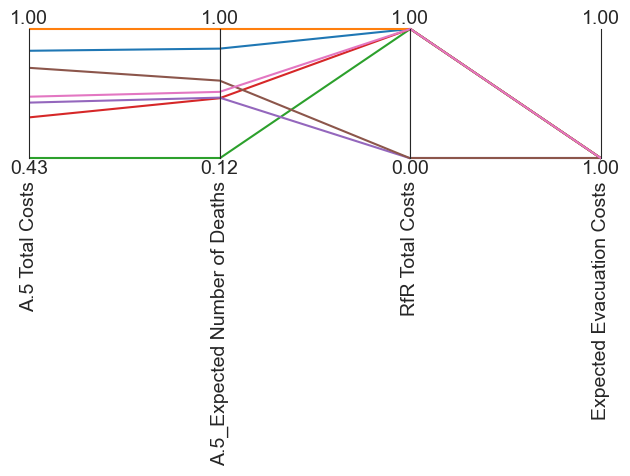

In [82]:
limits = parcoords.get_limits(overall_scores)
paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(overall_scores)
plt.show()

In [ ]:
len(all_results)

In [ ]:
import numpy as np

scenario_policy_counts = []

runs_per_scenario = 5
num_scenarios = len(all_results) // runs_per_scenario

for scenario_id in range(num_scenarios):
    scenario_valid_count = 0

    for run_id in range(runs_per_scenario):
        index = scenario_id * runs_per_scenario + run_id
        result_df = all_results[index]

        valid = (
                (result_df['A.5_Expected Number of Deaths'] < 1e-32) &
                (result_df['A.5 Total Costs'] < 60_000_000)
        )

        scenario_valid_count += np.sum(valid)

    scenario_policy_counts.append(scenario_valid_count)
    print(f"Scenario {scenario_id}: {scenario_valid_count} valid policies")







In [ ]:
results

In [ ]:
import pandas as pd
import numpy as np
from ema_workbench import Policy

valid_policy_dfs = []
scenario_policy_counts = []
policies_to_evaluate = []

runs_per_scenario = 5
num_scenarios = len(all_results) // runs_per_scenario

for scenario_id in range(num_scenarios):
    scenario_valid_count = 0

    for run_id in range(runs_per_scenario):
        index = scenario_id * runs_per_scenario + run_id
        result_df = all_results[index]

        # Apply constraints
        valid = (
            (result_df['A.5_Expected Number of Deaths'] < 1e-32) &
            (result_df['A.5 Total Costs'] < 60_000_000)
        )

        # Extract valid rows
        valid_rows = result_df[valid]

        # Drop only the objective columns (not all outcomes)
        lever_only_df = valid_rows.drop(columns=objectives_of_interest)

        scenario_valid_count += len(lever_only_df)
        valid_policy_dfs.append(lever_only_df)

    scenario_policy_counts.append(scenario_valid_count)
    print(f"Scenario {scenario_id}: {scenario_valid_count} valid policies")

# Combine all valid policies
policies = pd.concat(valid_policy_dfs, ignore_index=True)

# Convert each row into a Policy object
for i, policy in policies.iterrows():
    policies_to_evaluate.append(Policy(str(i), **policy.to_dict()))

print(f"\n✅ Total valid policies created: {len(policies_to_evaluate)}")




In [ ]:
policies_to_evaluate

In [ ]:
n_scenarios = 100
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios,
                                            policies_to_evaluate)

In [83]:
from ema_workbench import (
    Model,
    MultiprocessingEvaluator,
    ScalarOutcome,
    IntegerParameter,
    optimize,
    Scenario,
)


def s_to_n(data, direction):
    mean = np.mean(data)
    std = np.std(data)

    if direction == ScalarOutcome.MAXIMIZE:
        return mean / std
    else:
        return mean * std

In [84]:
experiments, outcomes = reeevaluation_results

overall_scores = {}
for policy in np.unique(experiments['policy']):
    scores = {}

    logical = experiments['policy'] == policy

    for outcome in dike_model.outcomes:
        value = outcomes[outcome.name][logical]
        sn_ratio = s_to_n(value, outcome.kind)
        scores[outcome.name] = sn_ratio
    overall_scores[policy] = scores
scores = pd.DataFrame.from_dict(overall_scores).T
scores

,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,1.711904e+16,8.562683e-04,6.980434e+15,0.000326,2.185882e+17,0.684276,1.306667e+14,5.443640e-07,4.836560e+15,1.596914e-03,0.0,0.0
1,8.910707e+13,2.971646e-09,3.595653e+16,0.028891,1.610433e+16,0.019465,8.664688e+13,1.067502e-07,3.037807e+13,9.063475e-09,0.0,0.0
2,3.410296e+17,1.398163e-01,1.185836e+16,0.001245,2.764426e+16,0.043357,5.613920e+13,2.453522e-08,3.731446e+16,3.092652e-02,0.0,0.0
3,1.958778e+16,1.027558e-03,3.562813e+16,0.028567,1.251283e+16,0.009182,6.686615e+13,8.446250e-08,2.700885e+16,1.825843e-02,0.0,0.0
4,2.798792e+16,1.947186e-03,3.096887e+16,0.024541,2.352146e+15,0.000143,4.006325e+13,2.687166e-08,1.414754e+16,1.134693e-02,0.0,0.0
5,9.758981e+13,1.188658e-08,2.730495e+16,0.021450,1.468706e+15,0.000147,5.270123e+13,3.656486e-08,4.347612e+15,3.383832e-03,0.0,0.0
6,8.642624e+15,2.619087e-04,1.015429e+15,0.000007,9.302444e+15,0.005186,1.808352e+15,3.947099e-04,1.521050e+16,9.196133e-03,0.0,0.0


/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x1200 with 0 Axes>

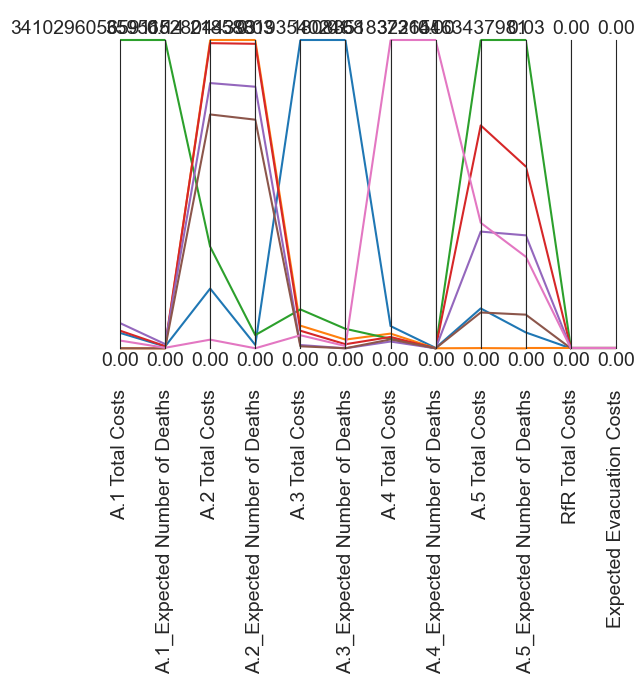

In [85]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = scores
limits = parcoords.get_limits(data)
limits.loc[0, [
    'A.1 Total Costs',
    'A.1_Expected Number of Deaths',
    'A.2 Total Costs',
    'A.2_Expected Number of Deaths',
    'A.3 Total Costs',
    'A.3_Expected Number of Deaths',
    'A.4 Total Costs',
    'A.4_Expected Number of Deaths',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]] = 0

plt.figure(figsize=(60, 12))  # make the figure wider; adjust numbers as you want

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)
#paraxes.invert_axis('A.5_Expected Number of Deaths')
plt.show()
#nog even duidelijker  maken

<Figure size 1200x600 with 0 Axes>

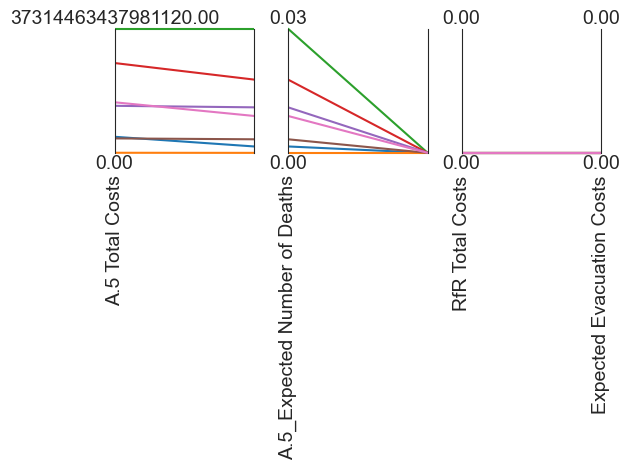

In [86]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

# Define the selected outcomes to focus on
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Filter the data to only include selected outcomes
filtered_data = scores[selected_outcomes]

# Get limits and set lower bounds to 0
limits = parcoords.get_limits(filtered_data)
limits.loc[0, selected_outcomes] = 0

# Create the plot
plt.figure(figsize=(12, 6))  # Adjusted to match reduced number of axes

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(filtered_data)

# Optionally invert axes if you want low deaths to be visually higher
# paraxes.invert_axis('A.5_Expected Number of Deaths')

plt.tight_layout()
plt.show()


In [87]:
def calculate_regret(data, best):
    return np.abs(best - data)

In [88]:
experiments, outcomes = reeevaluation_results

overall_regret = {}
max_regret = {}
for outcome in dike_model.outcomes:
    policy_column = experiments['policy']

    # create a DataFrame with all the relevent information
    # i.e., policy, scenario_id, and scores
    data = pd.DataFrame({outcome.name: outcomes[outcome.name],
                         "policy": experiments['policy'],
                         "scenario": experiments['scenario']})

    # reorient the data by indexing with policy and scenario id
    data = data.pivot(index='scenario', columns='policy')

    # flatten the resulting hierarchical index resulting from
    # pivoting, (might be a nicer solution possible)
    data.columns = data.columns.get_level_values(1)

    # we need to control the broadcasting.
    # max returns a 1d vector across scenario id. By passing
    # np.newaxis we ensure that the shape is the same as the data
    # next we take the absolute value
    #
    # basically we take the difference of the maximum across
    # the row and the actual values in the row
    #
    outcome_regret = (data.max(axis=1).values[:, np.newaxis] - data).abs()

    overall_regret[outcome.name] = outcome_regret
    max_regret[outcome.name] = outcome_regret.max()

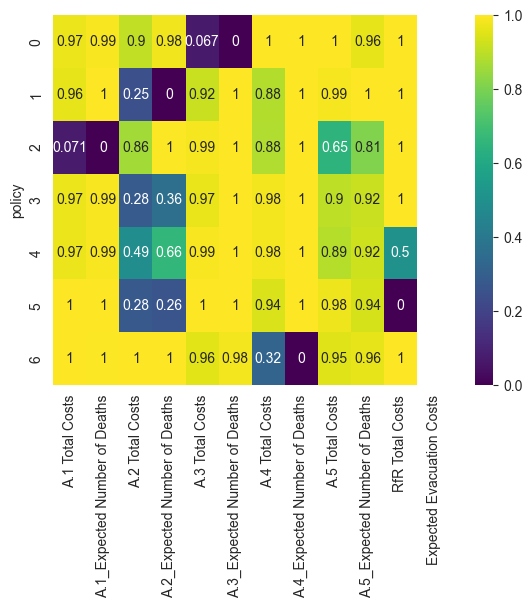

In [89]:
max_regret = pd.DataFrame(max_regret)
sns.heatmap(max_regret / max_regret.max(), cmap='viridis', annot=True)
plt.show()

/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)
/Users/batuhantazegul/Documents/EPA/2425/Q4/EPA141A/aaaaaaa/ema_workbench/analysis/parcoords.py:281: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


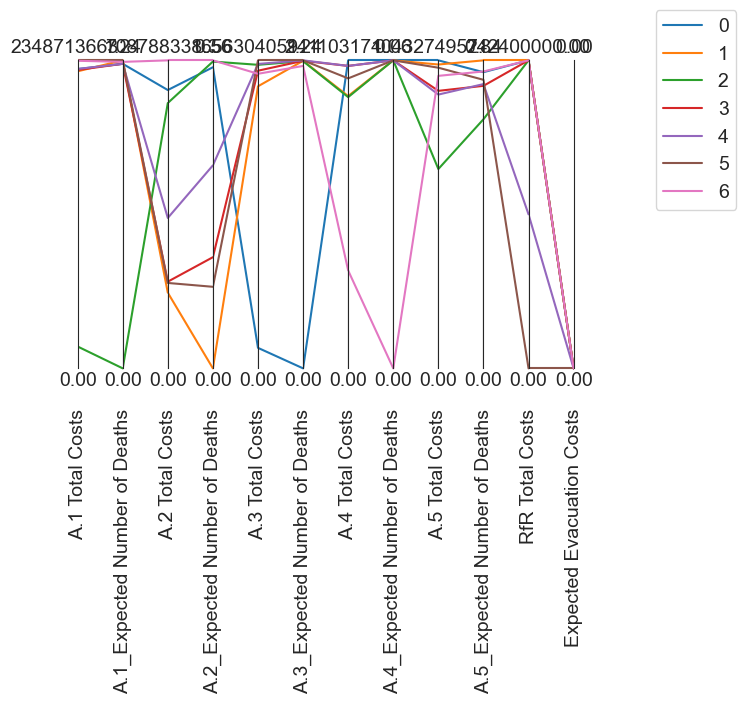

In [91]:
colors = sns.color_palette()

data = max_regret

# makes it easier to identify the policy associated with each line
# in the parcoords plot
# data['policy'] = data.index.astype("float64")

limits = parcoords.get_limits(data)
limits.loc[0, [
    'A.1 Total Costs',
    'A.1_Expected Number of Deaths',
    'A.2 Total Costs',
    'A.2_Expected Number of Deaths',
    'A.3 Total Costs',
    'A.3_Expected Number of Deaths',
    'A.4 Total Costs',
    'A.4_Expected Number of Deaths',
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]] = 0

paraxes = parcoords.ParallelAxes(limits)
for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i])
paraxes.legend()

plt.show()

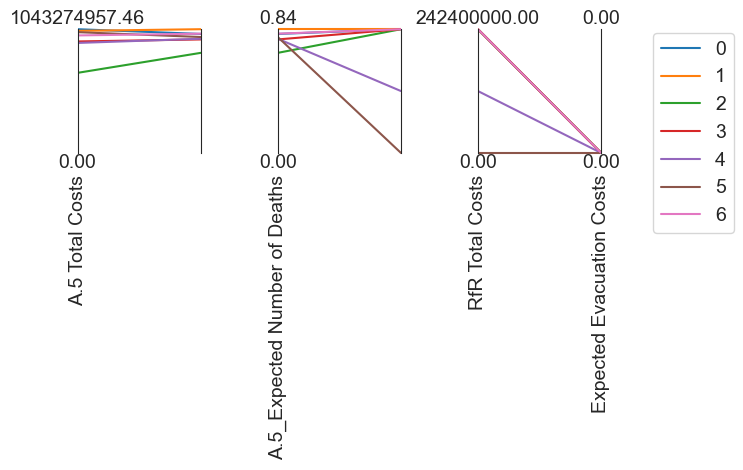

In [92]:
#betere leesbaarheid dan de vorige
import seaborn as sns
from ema_workbench.analysis import parcoords

colors = sns.color_palette()

# Select only the outcomes you want to plot
selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Filter the data to just those columns
data = max_regret[selected_outcomes]

# Set limits, and force minimums to 0
limits = parcoords.get_limits(data)
limits.loc[0, selected_outcomes] = 0  # Force y-axis minimums

# Create and draw parallel coordinate plot
paraxes = parcoords.ParallelAxes(limits)

for i, (index, row) in enumerate(data.iterrows()):
    paraxes.plot(row.to_frame().T, label=str(index), color=colors[i % len(colors)])

paraxes.legend()
plt.tight_layout()
plt.show()


In [93]:
from collections import defaultdict

policy_regret = defaultdict(dict)
for key, value in overall_regret.items():
    for policy in value:
        policy_regret[policy][key] = value[policy]

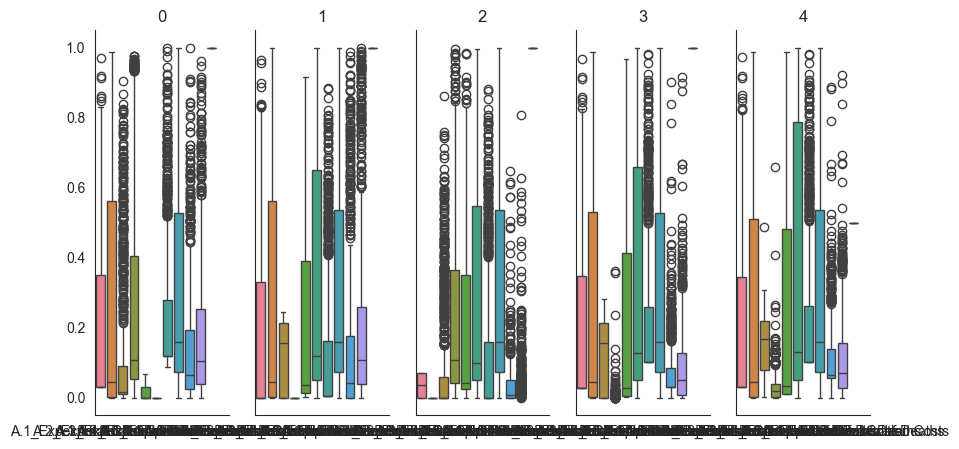

In [94]:
# this generates a 2 plots with a shared y and x axis
fig, axes = plt.subplots(ncols=5, figsize=(10, 5),
                         sharey=True, sharex=True)

# to ensure easy iteration over the axes grid, we turn it
# into a list. Because there are four plots, I hard coded
# this.


# zip allows us to zip together the list of axes and the list of
# key value pairs return by items. If we iterate over this
# it returns a tuple of length 2. The first item is the ax
# the second items is the key value pair.
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)

    # we need to scale the regret to ensure fair visual
    # comparison. We can do that by divding by the maximum regret
    data = data / max_regret.max(axis=0)
    sns.boxplot(data=data, ax=ax)

    # removes top and left hand black outline of axes
    sns.despine()

    # ensure we know which policy the figure is for
    ax.set_title(str(policy))
plt.show()

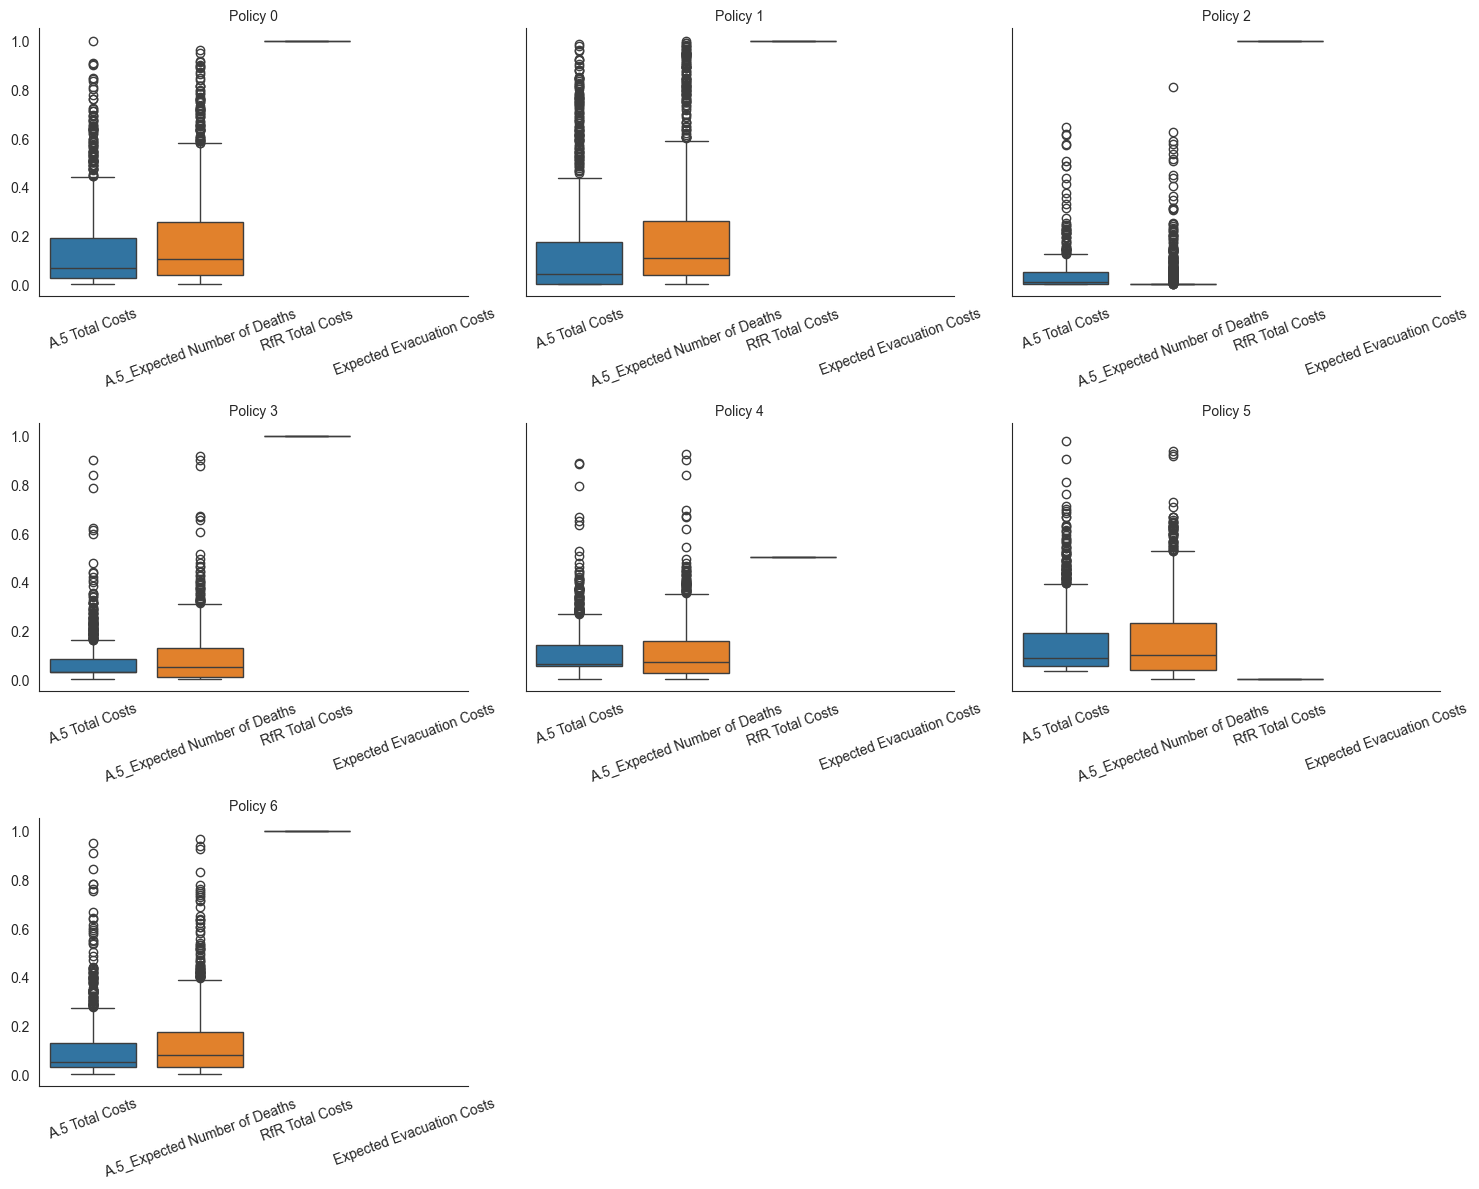

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_outcomes = [
    'A.5 Total Costs',
    'A.5_Expected Number of Deaths',
    'RfR Total Costs',
    'Expected Evacuation Costs'
]

# Calculate number of policies
num_policies = len(policy_regret)
ncols = 3  # columns in grid
nrows = int(np.ceil(num_policies / ncols))  # rows in grid

# Create grid of subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4), sharey=True)

# Flatten axes for easier indexing
axes = axes.flatten()

# Loop through policies and plot
for ax, (policy, regret) in zip(axes, policy_regret.items()):
    data = pd.DataFrame(regret)
    data = data / max_regret.max(axis=0)
    data = data[selected_outcomes]

    sns.boxplot(data=data, ax=ax)
    ax.set_title(f"Policy {policy}", fontsize=10)
    ax.tick_params(axis='x', labelrotation=20)  # Rotate labels for readability
    sns.despine()

# Hide unused axes if any
for ax in axes[len(policy_regret):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

